# Deep Learning Coursework [CSC8637]

---

* **Student Name:** [ Krishnanand Sagar ]
* **Student Number:** [ 250569452 ]
* **Module:** CSC8637 - Deep Learning
* **Date:** 20th February 2026


---

### **Introduction**

This notebook contains the complete implementation for the CSC8637 Deep Learning coursework. The project is divided into two distinct tasks focusing on Computer Vision and Natural Language Processing (NLP).

**Task 1: Fine-Grained Image Classification**
The objective is to classify bird species from the Caltech-UCSD Birds-200-2011 (CUB-200) dataset. This section implements and compares two approaches:
1.  **Transfer Learning:** Utilizing a pre-trained **EfficientNet-B3** model fine-tuned on the dataset.
2.  **Custom Architecture:** A Convolutional Neural Network (CNN) designed and trained from scratch to demonstrate the challenges of training deep networks on small datasets.
*Performance metrics evaluated:* Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.

**Task 2: Language Modelling**
The objective is to train a generative language model on the text of Agatha Christie's *"Poirot Investigates"*. This section implements:
1.  **Transformer Architecture:** A word-level language model using Multi-Head Attention and Positional Encoding.
2.  **Text Generation:** A pipeline to generate stylistic text based on user prompts.
*Evaluation:* Loss analysis and qualitative comparison of generated text against Large Language Models (LLMs).

---
**Note to Marker:**
* Please ensure the dataset files (`bird_CUB_200_2011.zip` and `61262-0.txt`) are available in the runtime environment or mounted via Google Drive as specified in the import cells.
* **Reproducibility:** A random seed (`42`) has been set globally to ensure results are consistent with the report.

## TASK 1 - Fine - Grained Classification:


### Part 1 - Transfer Learning

#### 1. Dataset Extraction and Directory Setup:

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/DL/bird_CUB_200_2011.zip"
extract_path = "/content/birds"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

Extraction complete.


#### 2. Imports and Reproducibility:

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from torch.cuda.amp import GradScaler

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


#### 3. Data Paths:

In [ ]:
data_root = "/content/birds/CUB_200_2011"

images_path = os.path.join(data_root, "images")
split_file = os.path.join(data_root, "train_test_split.txt")
labels_file = os.path.join(data_root, "image_class_labels.txt")
images_file = os.path.join(data_root, "images.txt")

#### 4. Load Official Split:

In [ ]:
images_df = pd.read_csv(images_file, sep=" ", names=["img_id", "filepath"])
labels_df = pd.read_csv(labels_file, sep=" ", names=["img_id", "label"])
split_df = pd.read_csv(split_file, sep=" ", names=["img_id", "is_train"])

data_df = images_df.merge(labels_df, on="img_id")
data_df = data_df.merge(split_df, on="img_id")

data_df["label"] -= 1

train_df = data_df[data_df["is_train"] == 1]
test_df = data_df[data_df["is_train"] == 0]

train_df, val_df = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 5394
Val: 600
Test: 5794


#### 5. Transforms (Native EfficientNet-B3 Resolution):

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(300),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3,0.3,0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

#### 6. Dataset Class:

In [ ]:
class CUBDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(images_path, row["filepath"])
        image = Image.open(img_path).convert("RGB")
        label = row["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

#### 7. DataLoaders:

In [ ]:
batch_size = 32

train_loader = DataLoader(
    CUBDataset(train_df, train_transform),
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    CUBDataset(val_df, val_test_transform),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    CUBDataset(test_df, val_test_transform),
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

#### 8. Model:

In [ ]:
model = timm.create_model(
    "efficientnet_b3",
    pretrained=True,
    num_classes=200,
    drop_rate=0.3
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

#### 9. Loss + Optimizer (Differential LR):

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Separate classifier parameters from the rest of the model parameters
classifier_params = model.get_classifier().parameters()
base_params = [p for n, p in model.named_parameters() if 'classifier' not in n]

optimizer = optim.AdamW([
    {"params": classifier_params, "lr": 3e-4},
    {"params": base_params, "lr": 1e-5}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=45)

scaler = torch.amp.GradScaler('cuda')

#### 10. Training Function

In [ ]:
def evaluate_accuracy(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return accuracy_score(all_labels, all_preds)


def train_model(model, train_loader, val_loader, epochs=45):
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        val_acc = evaluate_accuracy(model, val_loader)

        print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_efficientnet_b3_cub.pth")

    print("Training Complete.")

#### 11. Train

In [ ]:
train_model(model, train_loader, val_loader, epochs=45)

Epoch 1/45 | Loss: 869.1346 | Val Acc: 0.1600
Epoch 2/45 | Loss: 742.5388 | Val Acc: 0.3700
Epoch 3/45 | Loss: 609.4462 | Val Acc: 0.4933
Epoch 4/45 | Loss: 513.7553 | Val Acc: 0.5533
Epoch 5/45 | Loss: 454.5189 | Val Acc: 0.6117
Epoch 6/45 | Loss: 420.9963 | Val Acc: 0.6350
Epoch 7/45 | Loss: 394.3634 | Val Acc: 0.6633
Epoch 8/45 | Loss: 375.1702 | Val Acc: 0.6817
Epoch 9/45 | Loss: 361.5449 | Val Acc: 0.7200
Epoch 10/45 | Loss: 350.9714 | Val Acc: 0.6983
Epoch 11/45 | Loss: 341.2769 | Val Acc: 0.7150
Epoch 12/45 | Loss: 332.3870 | Val Acc: 0.7367
Epoch 13/45 | Loss: 326.0702 | Val Acc: 0.7417
Epoch 14/45 | Loss: 320.5737 | Val Acc: 0.7483
Epoch 15/45 | Loss: 318.5911 | Val Acc: 0.7433
Epoch 16/45 | Loss: 308.5125 | Val Acc: 0.7450
Epoch 17/45 | Loss: 307.5726 | Val Acc: 0.7500
Epoch 18/45 | Loss: 305.3751 | Val Acc: 0.7600
Epoch 19/45 | Loss: 302.1589 | Val Acc: 0.7617
Epoch 20/45 | Loss: 300.0706 | Val Acc: 0.7567
Epoch 21/45 | Loss: 296.2787 | Val Acc: 0.7617
Epoch 22/45 | Loss: 29

#### 12. Final Test Evaluation:

In [ ]:
model.load_state_dict(torch.load("best_efficientnet_b3_cub.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
cm = confusion_matrix(all_labels, all_preds)

print("FINAL TEST RESULTS")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

FINAL TEST RESULTS
Accuracy: 0.7780462547462893
Precision: 0.7880763759413872
Recall: 0.7804840402998693
F1 Score: 0.7792656023002859


#### 13. Confusion Matrix Plot:

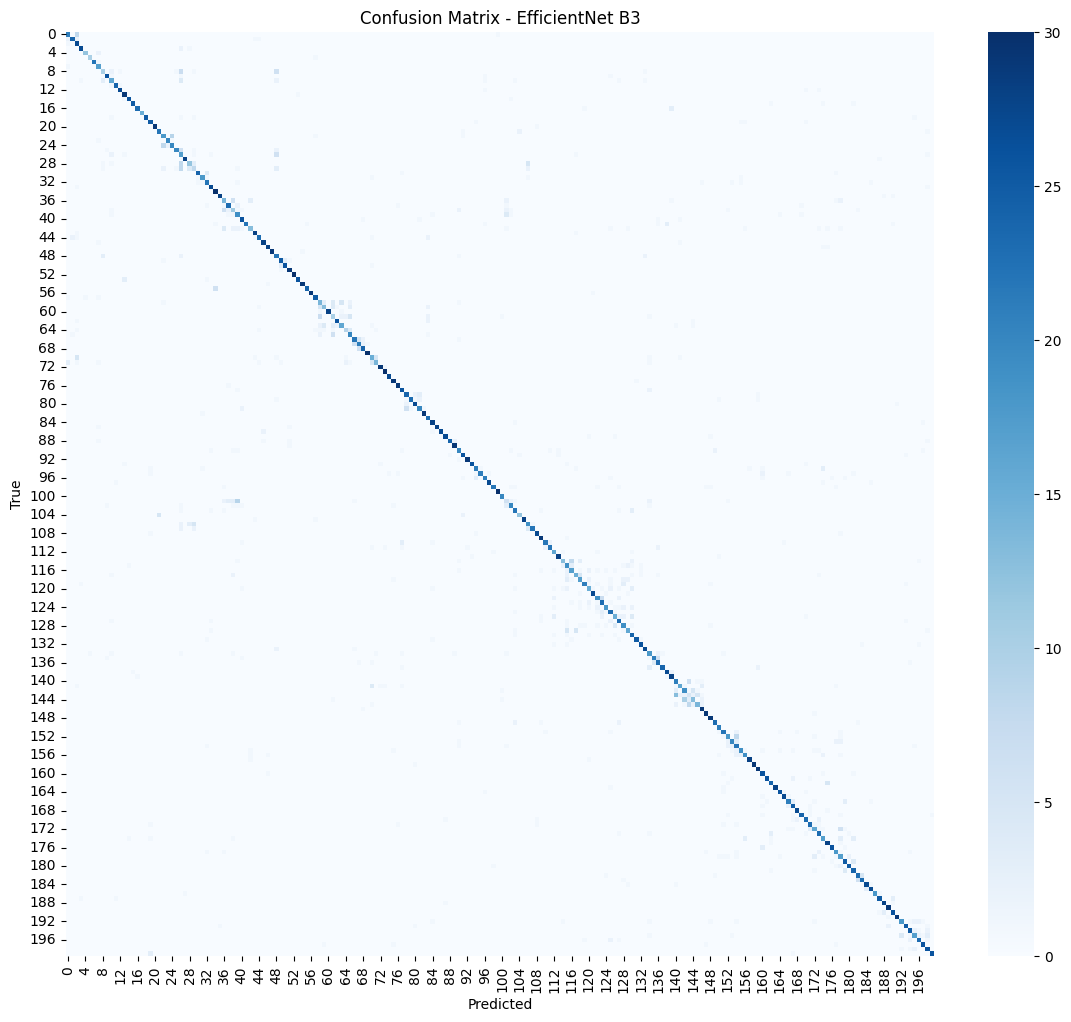

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - EfficientNet B3")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Part 2 - Custom Architecture

#### 1. Custom Model

In [ ]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=200):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

#### 2. Initialize model

In [ ]:
num_classes = 200
custom_model = CustomCNN(num_classes=num_classes).to(device)

#### 3. Define Loss, Optimizer, Scheduler

In [ ]:
criterion_custom = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_custom = torch.optim.AdamW(
    custom_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler_custom = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_custom,
    T_max=50
)

#### 4. Training Loop

In [ ]:
def train_custom_model(epochs=50):

    best_val_acc = 0.0

    for epoch in range(epochs):
        custom_model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer_custom.zero_grad()
            outputs = custom_model(images)
            loss = criterion_custom(outputs, labels)
            loss.backward()
            optimizer_custom.step()

            running_loss += loss.item()

        scheduler_custom.step()

        # --- Validation ---
        custom_model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = custom_model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {running_loss/len(train_loader):.4f} "
              f"Val Acc: {val_acc:.4f}")

        # --- Save Best Model ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': custom_model.state_dict(),
                'optimizer_state_dict': optimizer_custom.state_dict(),
                'val_accuracy': best_val_acc
            }, "best_custom_model.pth")

            print("✅ Best custom model saved.")

    print("Training complete.")
    print("Best Validation Accuracy:", best_val_acc)

#### 5. Train the Custom Model

In [ ]:
train_custom_model(epochs=50)

Epoch [1/50] Loss: 5.3031 Val Acc: 0.0200
✅ Best custom model saved.
Epoch [2/50] Loss: 5.1666 Val Acc: 0.0183
Epoch [3/50] Loss: 5.0941 Val Acc: 0.0400
✅ Best custom model saved.
Epoch [4/50] Loss: 5.0366 Val Acc: 0.0317
Epoch [5/50] Loss: 4.9962 Val Acc: 0.0283
Epoch [6/50] Loss: 4.9557 Val Acc: 0.0483
✅ Best custom model saved.
Epoch [7/50] Loss: 4.9081 Val Acc: 0.0433
Epoch [8/50] Loss: 4.8837 Val Acc: 0.0400
Epoch [9/50] Loss: 4.8557 Val Acc: 0.0433
Epoch [10/50] Loss: 4.7968 Val Acc: 0.0483
Epoch [11/50] Loss: 4.7740 Val Acc: 0.0600
✅ Best custom model saved.
Epoch [12/50] Loss: 4.7429 Val Acc: 0.0467
Epoch [13/50] Loss: 4.7167 Val Acc: 0.0683
✅ Best custom model saved.
Epoch [14/50] Loss: 4.7038 Val Acc: 0.0567
Epoch [15/50] Loss: 4.6531 Val Acc: 0.0617
Epoch [16/50] Loss: 4.6504 Val Acc: 0.0800
✅ Best custom model saved.
Epoch [17/50] Loss: 4.6239 Val Acc: 0.0750
Epoch [18/50] Loss: 4.5902 Val Acc: 0.0817
✅ Best custom model saved.
Epoch [19/50] Loss: 4.5717 Val Acc: 0.0850
✅ B

#### 6. Final Test Evaluation

In [ ]:
def evaluate(model, loader, detailed=False):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Accuracy: {acc:.4f}")

    if detailed:
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")

# Load best model
checkpoint = torch.load("best_custom_model.pth")
custom_model.load_state_dict(checkpoint['model_state_dict'])
custom_model.to(device)
custom_model.eval()

print("Loaded best model from epoch:", checkpoint['epoch'])

# Evaluate on test set
evaluate(custom_model, test_loader, detailed=True)

Loaded best model from epoch: 45
Accuracy: 0.1269
Precision: 0.1299
Recall: 0.1278
F1 Score: 0.1073


#### 7. Confusion Matrix Plot

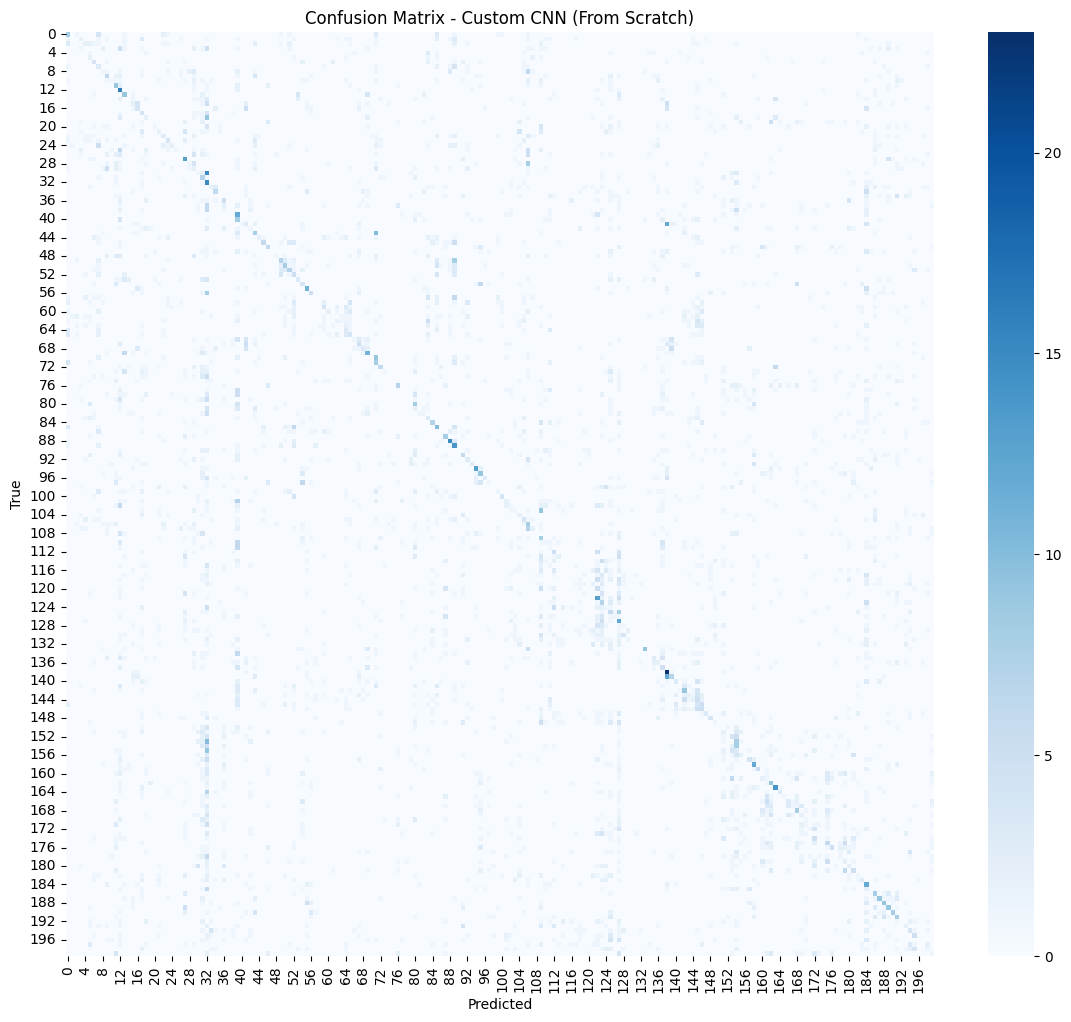

In [ ]:
from sklearn.metrics import confusion_matrix

custom_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = custom_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - Custom CNN (From Scratch)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### 8. Demo Setup:

In [ ]:
import zipfile
import os

zip_path = " " # Copy the Path of the zip File provided during demo
extract_path = "/content/demo"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete.")

In [ ]:
# Task 1 Setup
import torch
import timm
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- PATHS ---
t1_model_path = "/content/drive/MyDrive/DL/best_efficientnet_b3_cub.pth"
t1_data_dir = "/content/demo" # Copy the path of the demo folder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transform
t1_transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Function
def setup_task1_demo():
    model = timm.create_model('efficientnet_b3', pretrained=False, num_classes=200)
    if os.path.exists(t1_model_path):
        model.load_state_dict(torch.load(t1_model_path, map_location=device))
        print("✅ Task 1 Model loaded.")
    else:
        print("❌ Error: Task 1 Model file not found in root folder.")

    model.to(device)
    model.eval()

    try:
        dataset = datasets.ImageFolder(t1_data_dir, transform=t1_transform)
        loader = DataLoader(dataset, batch_size=32, shuffle=False)
        print(f"✅ Task 1 Data found: {len(dataset)} images.")
        return model, loader
    except:
        print(f"❌ Error: Could not find images at {t1_data_dir}")
        return None, None

t1_model, t1_loader = setup_task1_demo()

def run_task1_visuals():
    if t1_model is None: return "Error loading Task 1."

    all_preds, all_labels = [], []
    vis_imgs, vis_preds, vis_lbls = [], [], []

    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(t1_loader):
            imgs = imgs.to(device)
            out = t1_model(imgs)
            _, preds = torch.max(out, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.numpy())
            if i == 0:
                vis_imgs, vis_preds, vis_lbls = imgs.cpu(), preds.cpu(), lbls.cpu()

    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(f"Precision: {precision_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
    print(f"Recall: {recall_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")
    print(f"F1 Score: {f1_score(all_labels, all_preds, average='macro', zero_division=0):.4f}")

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(all_labels, all_preds), cmap='Blues', cbar=False)
    plt.show()

    fig, axes = plt.subplots(1, 5, figsize=(15,3))
    for i in range(5):
        img = vis_imgs[i].permute(1,2,0) * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
        axes[i].imshow(img.clamp(0,1))
        col = 'green' if vis_preds[i]==vis_lbls[i] else 'red'
        axes[i].set_title(f"P:{vis_preds[i]} T:{vis_lbls[i]}", color=col)
        axes[i].axis('off')
    plt.show()

### Demo Mode

In [ ]:
# Run Task 1 Demo
run_task1_visuals()

## TASK 2 - Language Modelling:

#### 1. Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import re
import os
from torch.utils.data import Dataset, DataLoader

#### 2. Device

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#### 3. Load and clean text

In [ ]:
file_path = "/content/drive/MyDrive/DL/61262-0.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

# Remove Gutenberg header/footer manually if needed
text = re.sub(r'\s+', ' ', text)
text = text.lower()

#### 4. Word Level Tokenization

In [ ]:
words = text.split()

vocab = sorted(set(words))
vocab_size = len(vocab)

word2idx = {w:i for i,w in enumerate(vocab)}
idx2word = {i:w for w,i in word2idx.items()}

encoded = [word2idx[w] for w in words]

#### 5. Dataset Creation

In [ ]:
SEQ_LEN = 40

class TextDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx:idx+self.seq_len])
        y = torch.tensor(self.data[idx+1:idx+self.seq_len+1])
        return x, y

dataset = TextDataset(encoded, SEQ_LEN)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

#### 6. Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

#### 7. Transformer Language Model

In [ ]:
class TransformerLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 256)
        self.pos_encoder = PositionalEncoding(256)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=1024,
            dropout=0.1,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        self.fc = nn.Linear(256, vocab_size)

    def generate_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1).bool()
        return mask.to(device)

    def forward(self, x):
        mask = self.generate_mask(x.size(1))
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x, mask)
        return self.fc(x)

#### 8. Initialize Model

In [ ]:
model = TransformerLM(vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


#### 9. Training Loop

In [ ]:
EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)

        loss = criterion(output.view(-1, vocab_size),
                         y.view(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader)}")

    torch.save(model.state_dict(),
               "/content/model.pth")

Epoch 1, Loss: 3.2656123584164676
Epoch 2, Loss: 0.6069214875031387
Epoch 3, Loss: 0.35435934615714937
Epoch 4, Loss: 0.2832058385693918
Epoch 5, Loss: 0.24713380624820397
Epoch 6, Loss: 0.22410822639349384
Epoch 7, Loss: 0.20888291755889324
Epoch 8, Loss: 0.1984348195664426
Epoch 9, Loss: 0.19038004294536034
Epoch 10, Loss: 0.18415298327848903
Epoch 11, Loss: 0.17878696053857862
Epoch 12, Loss: 0.17449367472556587
Epoch 13, Loss: 0.17015872694619882
Epoch 14, Loss: 0.16753646427465427
Epoch 15, Loss: 0.16453589684242173


#### 10. Demo Setup:

In [ ]:
# Task 2 Setup
import torch
import torch.nn as nn
import math
import re
import os

# Paths
t2_model_path = "/content/drive/MyDrive/DL/model.pth"
t2_book_path = "/content/drive/MyDrive/DL/61262-0.txt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Classes
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    def forward(self, x): return x + self.pe[:, :x.size(1)]

class TransformerLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 256)
        self.pos_encoder = PositionalEncoding(256)
        encoder_layer = nn.TransformerEncoderLayer(d_model=256, nhead=8, dim_feedforward=1024, dropout=0.1, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.fc = nn.Linear(256, vocab_size)
    def forward(self, x):
        mask = torch.triu(torch.ones(x.size(1), x.size(1)), diagonal=1).bool().to(device)
        x = self.embedding(x)
        x = self.pos_encoder(x)
        x = self.transformer(x, mask)
        return self.fc(x)

# Load Data & Model
def setup_task2_demo():
    # FIXED LINE: Returns 3 values now instead of 4
    if not os.path.exists(t2_book_path):
        print(f"❌ ERROR: File '{t2_book_path}' not found. Please upload it!")
        return None, None, None

    with open(t2_book_path, "r", encoding="utf-8") as f:
        words = re.sub(r'\s+', ' ', f.read()).lower().split()
    vocab = sorted(set(words))
    w2i = {w:i for i,w in enumerate(vocab)}
    i2w = {i:w for w,i in w2i.items()}

    model = TransformerLM(len(vocab)).to(device)
    if os.path.exists(t2_model_path):
        model.load_state_dict(torch.load(t2_model_path, map_location=device))
        print("✅ Model loaded successfully.")
    else:
        print("⚠️ Warning: 'model.pth' not found. Generating random text.")

    model.eval()
    return model, w2i, i2w

# Run Setup
t2_model, w2i, i2w = setup_task2_demo()

def generate_demo(prompt):
    if t2_model is None: return "Error: Model or Book not found."

    # Handle words not in vocab
    ids = []
    for w in prompt.lower().split():
        if w in w2i:
            ids.append(w2i[w])
        else:
            # Skip unknown words or use a placeholder if you have one
            continue

    if not ids: return "Error: Prompt words not in vocabulary."

    ids = torch.tensor(ids).unsqueeze(0).to(device)

    for _ in range(50):
        with torch.no_grad():
            out = t2_model(ids)
            # Temperature 0.7 for better results
            next_token = torch.multinomial(torch.softmax(out[:,-1,:]/0.7, -1), 1)
            ids = torch.cat([ids, next_token], 1)

    return " ".join([i2w[i.item()] for i in ids[0]])

### Demo Mode

In [ ]:
# Run Task 2 Demo
input_prompt = input("Enter prompt: ")
print(generate_demo(input_prompt))